# 1. Preparación del entorno

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np
import os, shutil, math
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
RUTA_DATA = r'C:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\Data'
# Detectar clases desde las subcarpetas
clases = sorted([c for c in os.listdir(RUTA_DATA)
                 if os.path.isdir(os.path.join(RUTA_DATA, c))])

In [3]:
print(f"{'Clases':<12} {'Imágenes por clase':>10}")
conteos = {}
for clase in clases:
    n = len(os.listdir(os.path.join(RUTA_DATA, clase)))
    conteos[clase] = n

total = sum(conteos.values())
for clase, n in conteos.items():
    print(f"{clase:<12} {n:>10}   {n/total*100:>5.1f}%")

print(f"{'TOTAL':<12} {total:>10}")

#Miro el tamaño de una imagen de ejemplo para saber a qué tamaño redimensionar después
primera_clase = clases[0]
primer_archivo = os.listdir(os.path.join(RUTA_DATA, primera_clase))[0]
img_muestra = Image.open(os.path.join(RUTA_DATA, primera_clase, primer_archivo))
print(f"\nTamaño de imagen: {img_muestra.size}")

Clases       Imágenes por clase
Angry             10148    17.2%
Fear               9732    16.5%
Happy             18439    31.2%
Sad               12553    21.2%
Suprise            8227    13.9%
TOTAL             59099

Tamaño de imagen: (48, 48)


Muestro un ejemplo de 5 imagenes por clase 

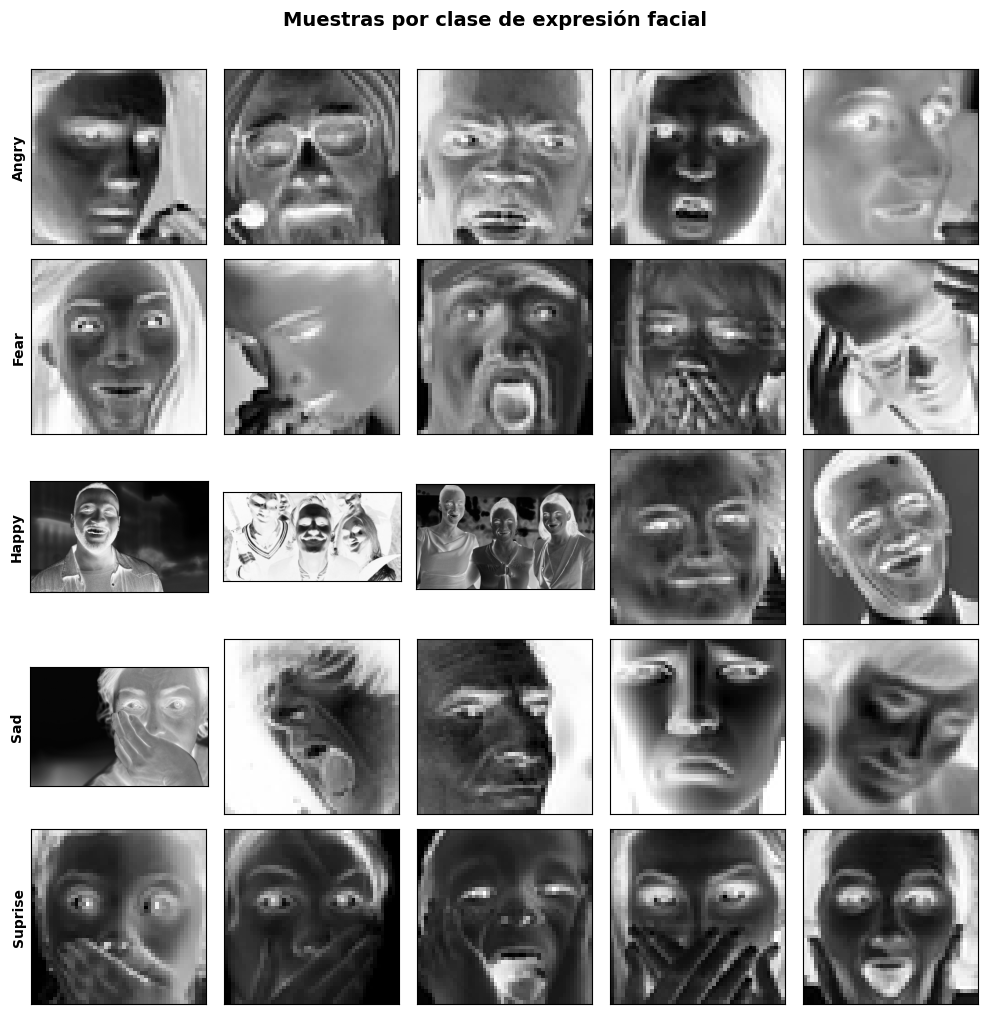

In [4]:
MUESTRAS_POR_CLASE = 5

fig, axes = plt.subplots(len(clases), MUESTRAS_POR_CLASE, figsize=(MUESTRAS_POR_CLASE * 2, len(clases) * 2))

for fila, clase in enumerate(clases):
    carpeta = os.path.join(RUTA_DATA, clase)
    archivos = os.listdir(carpeta)[:MUESTRAS_POR_CLASE]

    for col, archivo in enumerate(archivos):
        img = Image.open(os.path.join(carpeta, archivo)).convert('L')
        ax = axes[fila, col]
        ax.imshow(np.array(img), cmap=plt.cm.binary)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel(clase, fontsize=10, fontweight='bold')

plt.suptitle('Muestras por clase de expresión facial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Creo el Split de train, validacion y test en disco

In [5]:
# Proporciones 70 / 15 / 15
PROP_TRAIN = 0.70
PROP_VAL   = 0.15

RUTA_SPLIT = os.path.join(os.path.dirname(RUTA_DATA), 'Data_split')
RUTA_TRAIN = os.path.join(RUTA_SPLIT, 'train')
RUTA_VAL   = os.path.join(RUTA_SPLIT, 'val')
RUTA_TEST  = os.path.join(RUTA_SPLIT, 'test')

if os.path.exists(RUTA_SPLIT):
    print("⚠️  Data_split/ ya existe, no se repite la copia.")
else:
    np.random.seed(42)

    for clase in clases:
        archivos = np.array(os.listdir(os.path.join(RUTA_DATA, clase)))
        np.random.shuffle(archivos)

        n_total = len(archivos)
        n_train = int(n_total * PROP_TRAIN)
        n_val   = int(n_total * PROP_VAL)

        splits = {
            'train': archivos[:n_train],
            'val'  : archivos[n_train : n_train + n_val],
            'test' : archivos[n_train + n_val:]
        }

        for split_nombre, split_archivos in splits.items():
            destino = os.path.join(RUTA_SPLIT, split_nombre, clase)
            os.makedirs(destino, exist_ok=True)
            for archivo in split_archivos:
                shutil.copy(
                    os.path.join(RUTA_DATA, clase, archivo),
                    os.path.join(destino, archivo)
                )

    print("✅ Data_split/ creada")

# Verificar conteos
print(f"\n{'Clase':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)
for clase in clases:
    n_tr = len(os.listdir(os.path.join(RUTA_TRAIN, clase)))
    n_va = len(os.listdir(os.path.join(RUTA_VAL,   clase)))
    n_te = len(os.listdir(os.path.join(RUTA_TEST,  clase)))
    print(f"{clase:<12} {n_tr:>7} {n_va:>7} {n_te:>7}")

✅ Data_split/ creada

Clase          Train     Val    Test
-----------------------------------
Angry           7103    1522    1523
Fear            6812    1459    1461
Happy          12907    2765    2767
Sad             8787    1882    1884
Suprise         5758    1234    1235


Paso a hacer el procesamiento de los datos, basicamente prepararo las imágenes para que el modelo las pueda consumir durante el entrenamiento

In [7]:
TAMANO_IMG  = (48, 48)
TAMANO_LOTE = 32
NUM_CLASES  = len(clases)

# Generador TRAIN con augmentation y rescaling
generador_train = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 30,         
    width_shift_range  = 0.25,       
    height_shift_range = 0.25,       
    zoom_range         = [0.5, 1.5], 
    horizontal_flip    = True
)

# Generador VAL y TEST: en este caso solo normalización
generador_valtest = ImageDataGenerator(rescale=1./255)

Hemos usado ImageDataGenerator, que es una clase de Keras que hace dos cosas a la vez:
    - Normaliza las imágenes
    - Aplica transformaciones aleatorias
Los parámetros utilizados: 
    - rescale=1./255 : divide cada píxel por 255, después de esto quedan entre 0.0 y 1.0.
    - rotation_range=30 : rota cada imagen aleatoriamente entre -30° y +30°.
    - width_shift_range=0.25 : desplaza la imagen horizontalmente hasta un 25% del ancho.
    - height_shift_range=0.25 : igual pero vertical.
    - zoom_range=[0.5, 1.5] : aplica zoom aleatorio entre 50% (alejar) y 150% (acercar).
    - horizontal_flip=True : espeja la imagen horizontalmente de forma aleatoria, ya que una cara feliz espejada sigue siendo una cara feliz.

También tenemos el Generador de Validacion y test, pero a este solo le aplicamos normalización

Ahora pasamos a aplicar las transformaciones y normalización a TRAIN, TEST y VAL, como algún paramétro tenemos que destacar class_mode='categorical', este convierte las etiquetas a formato one-hot. Es decir, en lugar de decir clase 2, dice [0, 0, 1, 0, 0] y el shuffle=True, ya que mezcla las imágenes aleatoriamente en cada época para que el modelo no aprenda el orden

In [9]:
gen_train = generador_train.flow_from_directory(
    RUTA_TRAIN,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = True
)

gen_val = generador_valtest.flow_from_directory(
    RUTA_VAL,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)

gen_test = generador_valtest.flow_from_directory(
    RUTA_TEST,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)


Found 41367 images belonging to 5 classes.
Found 8862 images belonging to 5 classes.
Found 8870 images belonging to 5 classes.


Una vez transformadas la imagenes tenemos que asegurarnos de que la trandormación haya sido exitosa

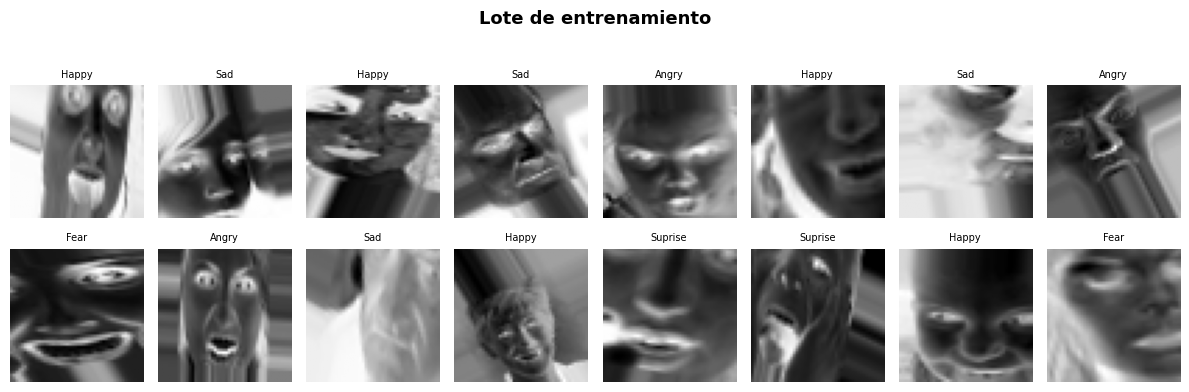

In [12]:
# primero pedimos un lote del generador de entrenamiento
X_batch, Y_batch = next(gen_train)

# obtengo el nombre de la clsae, por ejemplo -> 0: angry, 1: fear ...
idx_a_clase = {v: k for k, v in gen_train.class_indices.items()}

# representamos el lote para ver si las transformaciones se aplicaron
filas, columnas = 2, 8
fig, axes = plt.subplots(filas, columnas, figsize=(1.5 * columnas, 2 * filas))

for i in range(filas * columnas):
    ax = axes[i // columnas, i % columnas]
    ax.imshow(X_batch[i].reshape(TAMANO_IMG), cmap='gray_r')
    ax.set_title(idx_a_clase[np.argmax(Y_batch[i])], fontsize=7)
    ax.axis('off')

plt.suptitle('Lote de entrenamiento', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Implementación


Para poder encontrar el mejor modelo vamos a entrenar modelos con diferentes combinaciones de hiperparámetros, para eso vamos a definir un función que contrulle y compila un modelo según los hiperparámetros que se le pasan.

In [13]:
def construir_modelo(kernel_size, learning_rate):

    modelo = tf.keras.Sequential([

        #capa convolucional 1
        tf.keras.layers.Conv2D(32, (kernel_size, kernel_size), activation='relu', input_shape=(48, 48, 1)),
        tf.keras.layers.MaxPooling2D(2, 2),

        #capa convolucional 2
        tf.keras.layers.Conv2D(64, (kernel_size, kernel_size), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        #capa convolucional 3
        tf.keras.layers.Conv2D(128, (kernel_size, kernel_size), activation='relu', padding='same'),

        #dropout: esto desactiva aleatoriamente 50% de las neuronas durante el entrenamiento, previene overfitting y hace la red más robusta
        tf.keras.layers.Dropout(0.5),

        #clasificador
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation='relu'), #capa densa con 100 neuronas
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax') #capa de salida con tantas neuronas como clases
    ])

    #compilamos el modelo con Adam y categorical_crossentropy, porque usamos one-hot
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

Ahora definimos las combinaciones de hiperparámetros y hacemos el bucle de entrenamietno:


In [ ]:
combinaciones = [
    (3, 0.001),
    (3, 0.0005),
    (5, 0.001),
]
EPOCAS = 10

import time



resultados = []

for i, (kernel, lr) in enumerate(combinaciones):

    print(f"\n{'='*50}")
    print(f"Config {i+1}/{len(combinaciones)}: kernel={kernel}x{kernel} | lr={lr}")
    print(f"{'='*50}")

    modelo = construir_modelo(kernel, lr)

    hist = modelo.fit(
        gen_train, #generador de entrenamiento con augmentation
        epochs           = EPOCAS, 
        batch_size       = TAMANO_LOTE,
        steps_per_epoch  = int(np.ceil(gen_train.samples / TAMANO_LOTE)), #pasos por epoca
        validation_data  = gen_val, #datos de validación sin augmentation para monitorizar el overfitting
        validation_steps = int(np.ceil(gen_val.samples / TAMANO_LOTE)), #pasos de validación
        verbose          = 1
    )

    resultados.append({
        'kernel' : kernel,
        'lr'     : lr,
        'val_acc': hist.history['val_accuracy'][-1] * 100,
        'historial': hist
    })

#Imprimo el mejor modelo por pantalla
mejor = max(resultados, key=lambda x: x['val_acc'])
print("Mejor modelo:")
print(f"   kernel  : {mejor['kernel']}x{mejor['kernel']}")
print(f"   lr      : {mejor['lr']}")
print(f"   val_acc : {mejor['val_acc']:.2f}%")


Config 1/3: kernel=3x3 | lr=0.001


c:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 183s 140ms/step - accuracy: 0.3147 - loss: 1.5493 - val_accuracy: 0.3204 - val_loss: 1.5257
Epoch 2/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 112s 87ms/step - accuracy: 0.3269 - loss: 1.5316 - val_accuracy: 0.3615 - val_loss: 1.4855
Epoch 3/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 103s 80ms/step - accuracy: 0.3398 - loss: 1.5108 - val_accuracy: 0.3816 - val_loss: 1.4323
Epoch 4/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 146s 113ms/step - accuracy: 0.3575 - loss: 1.4852 - val_accuracy: 0.4190 - val_loss: 1.3657
Epoch 5/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 131s 101ms/step - accuracy: 0.3743 - loss: 1.4532 - val_accuracy: 0.4428 - val_loss: 1.3120
Epoch 6/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 108s 83ms/step - accuracy: 0.3926 - loss: 1.4193 - val_accuracy: 0.4768 - val_loss: 1.2510
Epoch 7/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 107s 83ms/step - accuracy: 0.4130 - loss: 1.3837 - val_accuracy: 0.4926 - val_loss: 1.2263
Epoch 8/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy:

In [ ]:
hist = mejor['historial']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'],     label='Train Loss', color='red',    linewidth=2)
plt.plot(hist.history['val_loss'], label='Val Loss',   color='orange', linewidth=2, linestyle='--')
plt.title('Loss')
plt.xlabel('Época')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'],     label='Train Accuracy', color='green', linewidth=2)
plt.plot(hist.history['val_accuracy'], label='Val Accuracy',   color='blue',  linewidth=2, linestyle='--')
plt.title('Accuracy')
plt.xlabel('Época')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()